# Notebook 05A - DistilBERT Fine-Tuning

## Transformer Model Setup: DistilBERT Environment Initialisation

This section initialises the environment for transformer-based modelling using DistilBERT. The required libraries for deep learning, data handling, evaluation, and visualisation are imported to support the end-to-end training pipeline.

PyTorch is used as the underlying deep learning framework, while the Hugging Face *transformers* library provides pre-trained models, tokenisers, and training utilities. The Trainer API is leveraged to streamline the training and evaluation process, including support for early stopping to prevent overfitting.

Scikit-learn utilities are included for dataset splitting, class imbalance handling, and performance evaluation. Additional metrics such as ROC-AUC and Precision–Recall AUC are used to ensure consistency with baseline model evaluation.

Project-specific configuration parameters are loaded centrally to maintain consistency in hyperparameters, dataset paths, and experimental settings across all transformer models.

Finally, a dedicated output directory is created for storing DistilBERT results and visualisations, and global plotting settings are applied to ensure a consistent visual style throughout this phase.

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch Utilities
import torch
from torch.utils.data import Dataset

# Visualisation and Warning Control
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers Components
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Evaluation Library
import evaluate

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    DISTILBERT_MODEL_ID,
    DISTILBERT_DIR,
    DISTILBERT_RESULTS_CSV,
    DISTILBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    NUM_EPOCHS,
    BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_STEPS,
    EARLY_STOPPING_PATIENCE,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    NUM_LABELS,
)


# Create Feature Analysis Plot Save Directory
DISTILBERT_PLOTS_DIR = PLOTS_DIR / "distilbert_model"
DISTILBERT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

## Data Preparation, Reproducibility, and Device Configuration

This section prepares the dataset for transformer-based modelling while ensuring reproducibility and efficient computation. A fixed random seed is applied across all components to guarantee consistent experimental results.

cuDNN settings are configured to optimise training performance when using GPU acceleration, balancing reproducibility and computational efficiency. The appropriate computation device is automatically selected, enabling seamless execution on either GPU or CPU environments. Mixed-precision training (FP16) is enabled when a GPU is available to improve training speed and memory efficiency.

The labelled dataset is then loaded, and narrative text along with corresponding labels are extracted. Similar to the baseline setup, the data is split into training, validation, and test sets using stratified sampling to preserve class distribution.

Finally, class weights are computed from the training data to address class imbalance, ensuring that the model remains sensitive to minority class instances during training. Summary statistics are displayed to verify the correctness of the data splits and class distribution.

In [2]:
# Reproducibility Setup
set_seed(RANDOM_STATE)

# cuDNN Configuration for Performance Optimisation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Device Selection 
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (device.type == 'cuda')

# Dataset Loading
df = pd.read_csv(LABELLED_DATASET)

# Feature and Label Extraction
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Class Weight Computation 
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

# Dataset Summary Statistics
print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Class weights : {cw_dict}')

Train : 28,876  |  Val : 3,610  |  Test : 3,610
Train label dist : [23325  5551]
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## Tokenisation and Dataset Construction

This section prepares the textual data for transformer-based modelling by converting raw narratives into tokenised inputs compatible with DistilBERT.

The pre-trained tokenizer is initialised using the DistilBERT model configuration, ensuring consistency with the model’s vocabulary and subword tokenisation scheme. Each narrative is tokenised with truncation and padding applied to a fixed maximum sequence length, enabling efficient batch processing.

A custom PyTorch `Dataset` class is implemented to encapsulate the tokenised inputs and corresponding labels. This class facilitates seamless integration with the Hugging Face Trainer API by returning input tensors and labels in the required format.

Separate dataset instances are created for training, validation, and testing, ensuring a clear separation of data across different stages of the modelling pipeline. This structured approach supports efficient training, evaluation, and reproducibility.

In [3]:
# Tokenizer Initialisation
tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_ID)

# Custom PyTorch Dataset for Tokenised Inputs
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        # Text Tokenisation (Padding + Truncation)
        self.enc = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        # Label Tensor Conversion
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Dataset Size
        return len(self.labels)

    def __getitem__(self, idx):
        # Retrieve Encoded Inputs and Corresponding Label
        item = {k: v[idx] for k, v in self.enc.items()}
        item['labels'] = self.labels[idx]
        return item

# Dataset Instantiation (Train / Validation / Test)
train_ds = ClinicalDataset(X_train, y_train, tokenizer)
val_ds = ClinicalDataset(X_val, y_val, tokenizer)
test_ds = ClinicalDataset(X_test, y_test, tokenizer)

# Confirmation Output
print(f'Datasets created  (max_length={MAX_LENGTH})')

Datasets created  (max_length=256)


## Custom Training Strategy and Evaluation Metrics

This section defines a customised training and evaluation framework for the DistilBERT model, incorporating class imbalance handling and comprehensive performance metrics.

To address class imbalance, a custom Trainer class is implemented by extending the Hugging Face Trainer API. This modification introduces a class-weighted cross-entropy loss function, ensuring that minority class samples contribute more significantly to the training objective.

The evaluation pipeline is designed to provide a multi-dimensional assessment of model performance. In addition to standard accuracy, weighted F1-score is computed to account for class imbalance. Probability-based metrics such as ROC-AUC and Precision–Recall AUC (PR-AUC) are also included, enabling threshold-independent evaluation and direct comparison with baseline models.

Predicted probabilities are obtained using a softmax transformation of model logits, ensuring compatibility with probabilistic evaluation metrics. Robust error handling is incorporated to manage edge cases where certain metrics may be undefined.

This customised setup ensures that the transformer model is both effectively trained under imbalanced conditions and evaluated using metrics that reflect real-world performance requirements.

In [4]:
# Custom Trainer with Class-Weighted Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Class Weight Tensor 
        w = torch.tensor(
            [class_weights[0], class_weights[1]],
            dtype=torch.float
        ).to(device)

        # Weighted Cross-Entropy Loss
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=w)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract Labels and Forward Pass
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # Compute Weighted Loss
        loss = self.loss_fn(outputs.logits, labels)

        return (loss, outputs) if return_outputs else loss


# Accuracy Metric Initialisation
acc_metric = evaluate.load('accuracy')


# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predictions and Probabilities
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1
    ).numpy()[:, 1]

    # Accuracy Computation
    acc = acc_metric.compute(
        predictions=preds,
        references=labels
    )['accuracy']

    # Classification Report (Weighted F1)
    rep = classification_report(
        labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    # ROC-AUC and PR-AUC 
    try:
        roc = roc_auc_score(labels, probs)
        pr  = average_precision_score(labels, probs)
    except ValueError:
        roc = pr = 0.0

    # Metric Dictionary
    return {
        'accuracy' : acc,
        'f1_weighted' : rep['weighted avg']['f1-score'],
        'roc_auc' : roc,
        'pr_auc' : pr,
    }

## Model Initialisation and Resource Monitoring

This section initialises the DistilBERT model for sequence classification and prepares it for training on the selected computation device.

Prior to model loading, GPU memory is optionally cleared to ensure efficient utilisation of available resources and to avoid memory fragmentation. This is particularly important when working with large transformer models in constrained environments.

The pre-trained DistilBERT model is then loaded with a classification head configured for the specific number of output labels. This enables fine-tuning of the model on the downstream readmission prediction task.

The model is moved to the appropriate device (GPU or CPU), ensuring compatibility with the training pipeline. Finally, the total and trainable parameter counts are reported to provide insight into model complexity and computational requirements.

Understanding the scale of the model is important for interpreting training time, memory usage, and potential overfitting behaviour.

In [5]:
# GPU Memory Check (Before Model Loading)
if device.type == 'cuda':
    torch.cuda.empty_cache()
    vram_before = torch.cuda.memory_allocated(0) / 1e9

# Model Initialisation 
model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_ID,
    num_labels=NUM_LABELS
)

# Move Model to Device
model.to(device)

# Parameter Count 
total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parameters  : {total_p:,} total  |  {trainable_p:,} trainable')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 918.21it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters  : 66,955,010 total  |  66,955,010 trainable


## Model Training Configuration and Fine-Tuning

This section defines the training configuration and executes fine-tuning of the DistilBERT model on the clinical narrative dataset.

Training is controlled באמצעות the Hugging Face `TrainingArguments`, which specify key hyperparameters such as learning rate, batch size, number of epochs, and weight decay. Warmup steps are included to stabilise training in the early stages, while mixed-precision training (FP16) is enabled when using GPU to improve computational efficiency.

Evaluation and model checkpointing are performed at the end of each epoch. The best model is automatically selected based on the ROC-AUC metric, ensuring alignment with the evaluation criteria used in baseline models. Early stopping is applied to prevent overfitting by terminating training when validation performance no longer improves.

The custom `WeightedTrainer` integrates class-weighted loss to address class imbalance, ensuring that minority class predictions are prioritised during optimisation.

Finally, the training process is executed, and total runtime is reported to provide insight into computational cost and scalability of the transformer-based approach.

In [6]:
# Training Arguments Configuration 
training_args = TrainingArguments(
    output_dir = DISTILBERT_DIR,
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate = LEARNING_RATE,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'roc_auc',
    greater_is_better = True,
    fp16 = USE_FP16,
    dataloader_pin_memory = (device.type == 'cuda'),
    dataloader_num_workers = 0,
    logging_steps = 50,
    report_to = 'none',
    seed = RANDOM_STATE,
)

# Trainer Initialisation 
trainer = WeightedTrainer(
    class_weights = cw_dict,
    model= model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

# Training Start Notification
print('Starting DistilBERT fine-tuning...')

# Model Training Execution
train_result = trainer.train()

# Training Runtime Summary
runtime_min = train_result.metrics['train_runtime'] / 60
print(f'Training complete in {runtime_min:.1f} min')

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Roc Auc,Pr Auc
1,0.632642,0.619752,0.700554,0.725214,0.710426,0.411339
2,0.627559,0.609890,0.678116,0.709029,0.725226,0.427551
3,0.606631,0.614975,0.722992,0.741212,0.725328,0.435414
4,0.554827,0.630168,0.714958,0.736648,0.718329,0.424966
5,0.510657,0.666812,0.678393,0.708373,0.710789,0.407193
6,0.453118,0.743041,0.690028,0.716279,0.699784,0.405950


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.12it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete in 14.0 min


## Training Dynamics and Convergence Analysis

This section analyses the training behaviour of the DistilBERT model using logged metrics collected during fine-tuning. Monitoring training dynamics is essential for understanding model convergence, stability, and potential overfitting.

Training loss is plotted against optimisation steps to assess how effectively the model minimises the objective function over time. A smooth and decreasing loss curve typically indicates stable learning.

Validation performance is evaluated across epochs using ROC-AUC and weighted F1-score. These metrics provide insight into generalisation performance and help identify the point at which the model achieves optimal validation performance.

By jointly analysing training loss and validation metrics, it becomes possible to diagnose issues such as overfitting (diverging validation performance) or underfitting (persistently low performance). This analysis also validates the effectiveness of early stopping and model selection strategies applied during training.

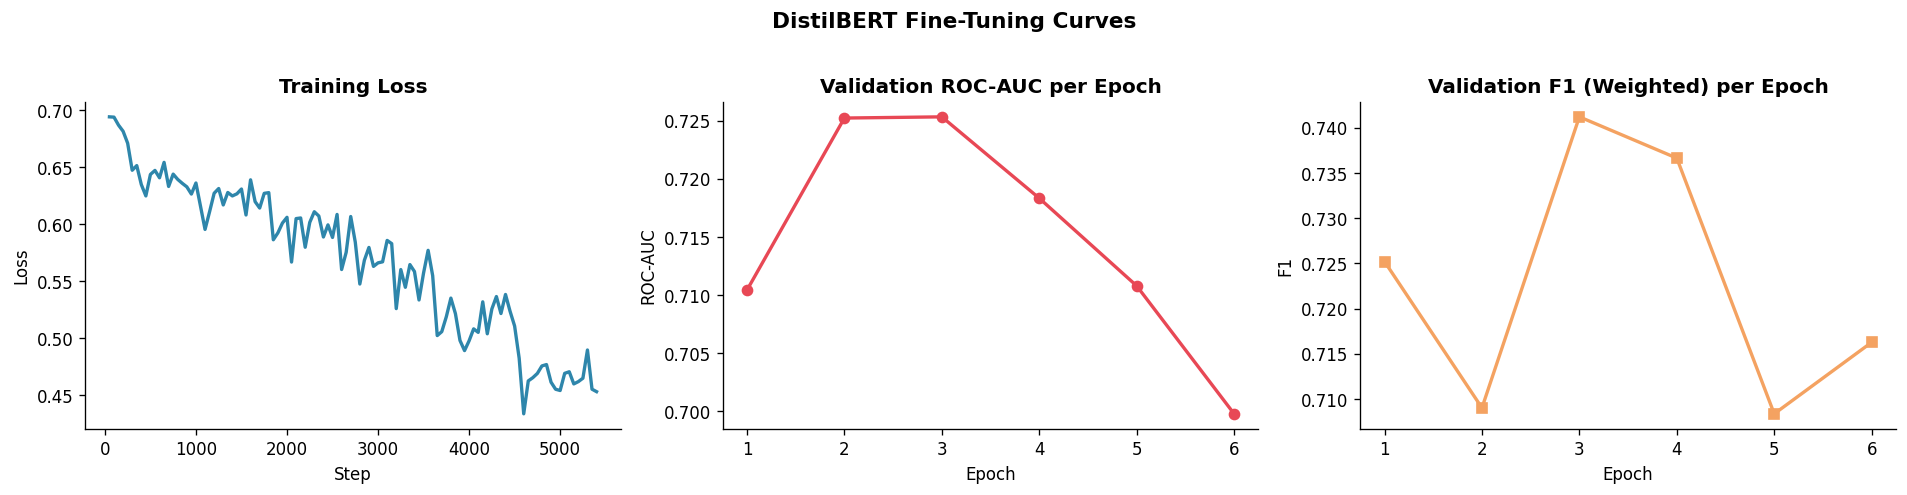

In [7]:
# Extract Training and Evaluation Logs
log_history = trainer.state.log_history

train_logs = [
    x for x in log_history
    if 'loss' in x and 'eval_loss' not in x
]

eval_logs = [
    x for x in log_history
    if 'eval_loss' in x
]

# Plot Training Curves 
if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Training Loss vs Steps
    axes[0].plot(
        [x['step'] for x in train_logs],
        [x['loss'] for x in train_logs],
        color=PALETTE[0],
        lw=2
    )
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    # Validation ROC-AUC per Epoch
    axes[1].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_roc_auc', 0) for x in eval_logs],
        'o-',
        color=PALETTE[1],
        lw=2,
        markersize=6
    )
    axes[1].set_title('Validation ROC-AUC per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')

    # Validation Weighted F1 per Epoch
    axes[2].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_f1_weighted', 0) for x in eval_logs],
        's-',
        color=PALETTE[2],
        lw=2,
        markersize=6
    )
    axes[2].set_title('Validation F1 (Weighted) per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')

    # Figure Formatting and Save
    plt.suptitle(
        'DistilBERT Fine-Tuning Curves',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()

    plt.savefig(
        f'{DISTILBERT_PLOTS_DIR}/db_01_training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

## Test Set Evaluation and Performance Analysis

This section evaluates the fine-tuned DistilBERT model on the held-out test set, providing a comprehensive assessment of its generalisation performance.

Predictions are generated using the trained model, and class probabilities are obtained באמצעות a softmax transformation of the output logits. These probabilities are used to compute threshold-independent evaluation metrics, including ROC-AUC and Precision–Recall AUC (PR-AUC), ensuring consistency with the baseline evaluation framework.

A detailed classification report is produced to summarise class-wise precision, recall, and F1-scores. This enables a deeper understanding of model performance across both majority and minority classes.

Visual evaluation is performed using ROC and Precision–Recall curves, which illustrate model behaviour across varying classification thresholds. A confusion matrix is also included to provide a granular view of prediction outcomes, highlighting true positives, false positives, false negatives, and true negatives.

Together, these analyses provide a robust and interpretable evaluation of the transformer model, enabling direct comparison with baseline approaches and supporting informed model selection.


 DistilBERT - Test Set Results 
                precision    recall  f1-score   support

Not Readmitted       0.87      0.75      0.81      2916
    Readmitted       0.33      0.51      0.40       694

      accuracy                           0.71      3610
     macro avg       0.60      0.63      0.60      3610
  weighted avg       0.76      0.71      0.73      3610

ROC-AUC : 0.7027   PR-AUC : 0.3964


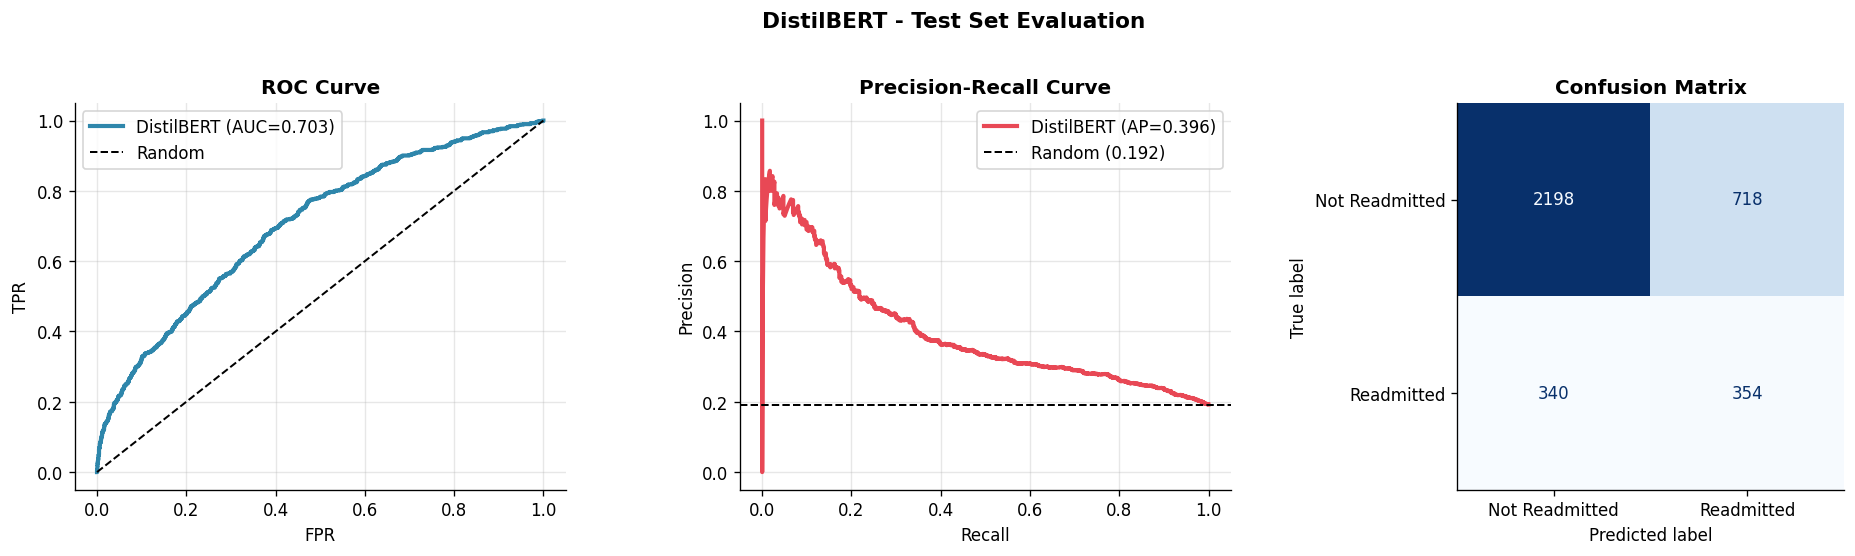

In [8]:
# Test Set Prediction
pred_out = trainer.predict(test_ds)

# Logits, Predicted Labels, and Probabilities
logits = pred_out.predictions
y_pred = np.argmax(logits, axis=-1)

y_prob = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

# Evaluation Metrics (Test Set)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Results Output
print('\n DistilBERT - Test Set Results ')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted'],
    zero_division=0
))
print(f'ROC-AUC : {roc_auc:.4f}   PR-AUC : {pr_auc:.4f}')

# Curve Computation (ROC and Precision-Recall)
fpr, tpr, _  = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC Curve
axes[0].plot(
    fpr, tpr,
    color=PALETTE[0],
    lw=2.5,
    label=f'DistilBERT (AUC={roc_auc:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(
    rec, prec,
    color=PALETTE[1],
    lw=2.5,
    label=f'DistilBERT (AP={pr_auc:.3f})'
)
axes[1].axhline(
    y=y_test.mean(),
    color='k',
    linestyle='--',
    lw=1.2,
    label=f'Random ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Readmitted', 'Readmitted']
).plot(ax=axes[2], colorbar=False, cmap='Blues')

axes[2].set_title('Confusion Matrix', fontweight='bold')

# Figure Formatting and Save
plt.suptitle(
    'DistilBERT - Test Set Evaluation',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

plt.savefig(
    f'{DISTILBERT_PLOTS_DIR}/db_02_test_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Prediction Confidence and Calibration Analysis

This section analyses the confidence of DistilBERT predictions to better understand model calibration and decision behaviour.

Predicted probabilities for the positive class (readmission) are examined under two perspectives. First, confidence distributions are analysed separately for true class labels, allowing assessment of how well the model distinguishes between readmitted and non-readmitted patients. Ideally, the distributions should be well separated, indicating strong discriminative capability.

Second, prediction confidence is analysed based on correctness, comparing correctly classified and misclassified instances. This provides insight into model calibration, as well-calibrated models tend to assign higher confidence to correct predictions and lower confidence to incorrect ones.

A decision threshold of 0.5 is visualised to highlight how predictions are mapped to class labels. Observing how probability mass is distributed around this threshold can reveal potential opportunities for threshold tuning.

Overall, this analysis complements traditional evaluation metrics by providing a deeper understanding of model certainty, reliability, and potential areas for improvement.

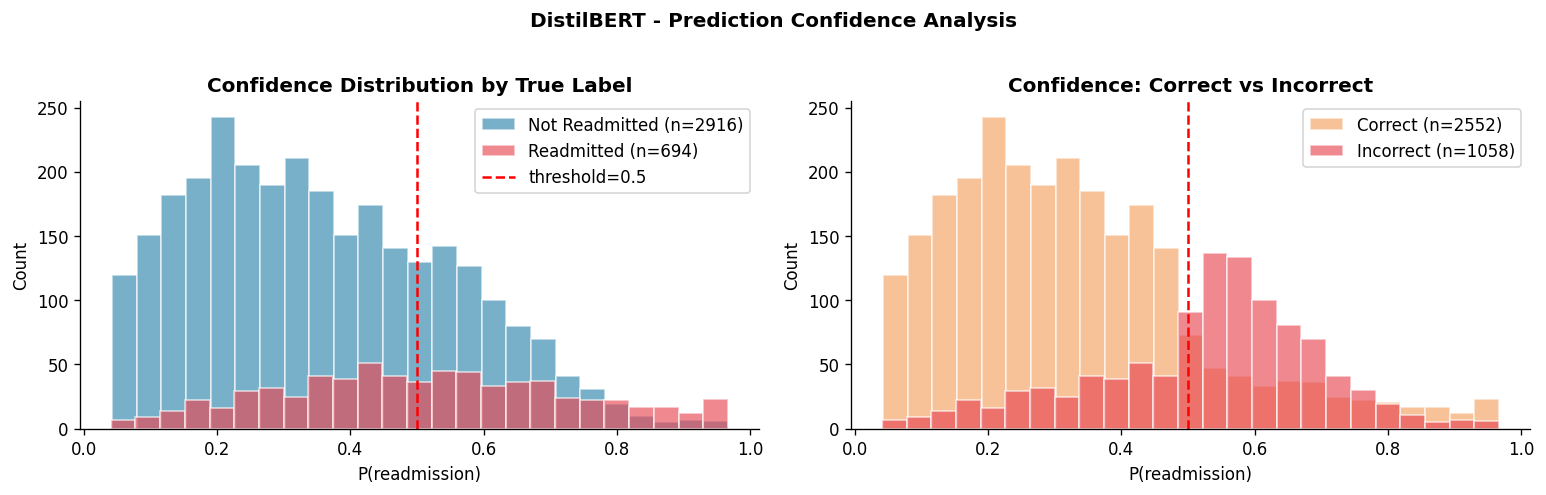

In [9]:
# Confidence Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence by True Label
for label, color, name in [
    (0, PALETTE[0], 'Not Readmitted'),
    (1, PALETTE[1], 'Readmitted')
]:
    sub = y_prob[y_test == label]

    axes[0].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{name} (n={len(sub)})'
    )

# Decision Threshold Line
axes[0].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5,
    label='threshold=0.5'
)

axes[0].set_title('Confidence Distribution by True Label', fontweight='bold')
axes[0].set_xlabel('P(readmission)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by Prediction Correctness
correct = (y_pred == y_test)

for flag, color, lbl in [
    (True, PALETTE[2], 'Correct'),
    (False, PALETTE[1], 'Incorrect')
]:
    sub = y_prob[correct == flag]

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{lbl} (n={len(sub)})'
    )

# Decision Threshold Line
axes[1].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5
)

axes[1].set_title('Confidence: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('P(readmission)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    'DistilBERT - Prediction Confidence Analysis',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{DISTILBERT_PLOTS_DIR}/db_03_confidence_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Results Persistence and Artefact Storage

This section finalises the DistilBERT evaluation pipeline by storing model performance metrics and prediction artefacts for future analysis and reproducibility.

Key evaluation metrics, including accuracy, precision, recall, F1-scores, ROC-AUC, and PR-AUC, are saved in a structured CSV format. This enables straightforward comparison with baseline models and supports integration into summary tables for reporting.

In addition, all relevant prediction outputs and evaluation artefacts are serialised using pickle. These include true labels, predicted labels, predicted probabilities, and curve data for ROC and Precision–Recall analysis. Storing these artefacts ensures that results can be reproduced, re-evaluated, or visualised without requiring model retraining.

This step completes the transformer modelling pipeline and prepares the outputs for downstream comparison, reporting, and potential deployment.

In [10]:
# Save Evaluation Metrics to CSV
pd.DataFrame([{
    'Model' : 'DistilBERT',
    'Model_ID' : DISTILBERT_MODEL_ID,
    'Type' : 'Transformer',
    'Domain' : 'General English',
    'Accuracy' : report['accuracy'],
    'Precision_Pos' : report['1']['precision'],
    'Recall_Pos' : report['1']['recall'],
    'F1_Pos' : report['1']['f1-score'],
    'F1_Weighted' : report['weighted avg']['f1-score'],
    'ROC_AUC' : roc_auc,
    'PR_AUC' : pr_auc,
}]).to_csv(
    DISTILBERT_RESULTS_CSV,
    index=False
)

# Save Predictions and Evaluation Artifacts (Pickle)
with open(DISTILBERT_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'y_test' : y_test,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'X_test' : X_test,
        'report' : report,
        'roc_auc': roc_auc,
        'pr_auc' : pr_auc,
        'fpr' : fpr,
        'tpr' : tpr,
        'prec' : prec,
        'rec' : rec,
    }, f)

# Final Metric Summary
print(f'\nROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')


ROC-AUC : 0.7027  |  PR-AUC : 0.3964
